In [1]:
import phoebe
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams["font.size"] = 18
#rcParams["text.latex.preamble"] = r"\usepackage{cmbright}"
matplotlib.rcParams["savefig.dpi"] = 100
from phoebe.atmospheres import models
from phoebe.atmospheres.passbands import InterpQuery


Load passband of choice

In [2]:
pb=phoebe.get_passband('SDSS:gprime')

Get Inorm and LD coeffs for DA

In [3]:
DAquery=np.ones(len(pb.ndp['tmap_DA'].axes[0])*len(pb.ndp['tmap_DA'].axes[1]))
DAquery=np.array([DAquery,DAquery]).T
i=0
for x in range(0,len(pb.ndp['tmap_DA'].axes[0])):
    for y in range(0,len(pb.ndp['tmap_DA'].axes[1])):
        DAquery[i]=np.array([pb.ndp['tmap_DA'].axes[0][x],pb.ndp['tmap_DA'].axes[1][y]])
        i=i+1
query_table=InterpQuery(cols=['teffs','loggs'],pts=np.c_[DAquery])
DAlin=pb.interpolate_ldcoeffs(query_table,ldatm=models.TMAPDAModelAtmosphere,ld_func='linear')
DAInorm=pb.interpolate_inorms(query=query_table, atm=models.TMAPDAModelAtmosphere, ld_func='linear', ld_coeffs=[0.0]).get_interpolated_values()

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/var/folders/pg/hdw1chp161q7cjtzvbyw_zbc0000gq/T/ipykernel_3996/596758522.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$T_\mathrm{eff}$")


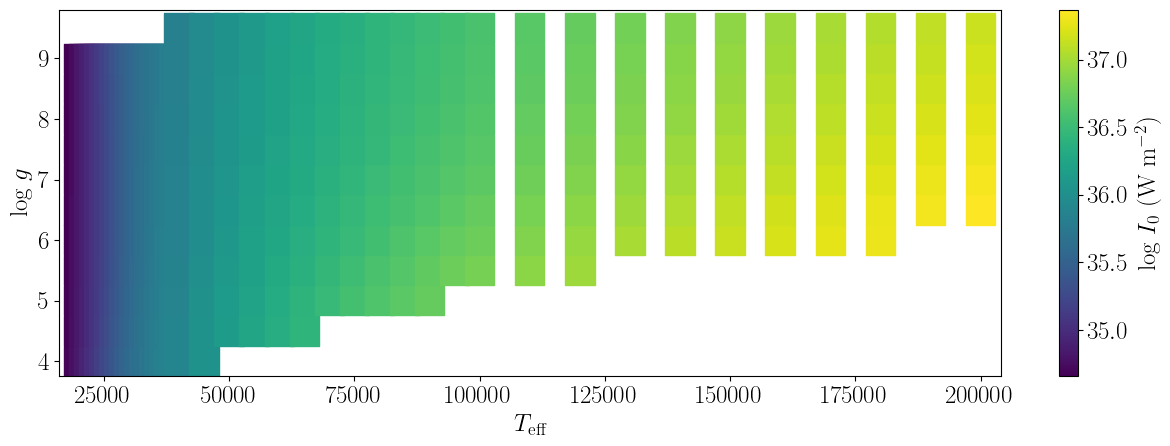

In [4]:
plt.figure(figsize=(12.8,4.8))
plt.scatter(DAquery.T[0][:],DAquery.T[1][:],c=np.log(DAInorm),marker="s",s=450)

plt.ylabel("log $g$")
plt.xlabel("$T_\mathrm{eff}$")
plt.ylim([3.75,9.8])
plt.xlim([16000,204000])
plt.colorbar(label="log $I_0$ (W~m$^{-2}$)")
plt.tight_layout()
